In [67]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt


In [68]:
import pandas as pd

url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt"
data = pd.read_csv(url, header=None)

print(data.shape)
data.head()

(125973, 43)


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [69]:
import numpy as np

numeric_data = data.select_dtypes(include=[np.number]).copy()

print(numeric_data.shape)
numeric_data.head()

(125973, 39)


,0,4,5,6,7,8,9,10,11,12,...,32,33,34,35,36,37,38,39,40,42
0,0,491,0,0,0,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,20
1,0,146,0,0,0,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,15
2,0,0,0,0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,19
3,0,232,8153,0,0,0,0,0,1,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,21
4,0,199,420,0,0,0,0,0,1,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,21


In [70]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05, random_state=42)
model.fit(numeric_data)

predictions = model.predict(numeric_data)
numeric_data["anomaly"] = predictions

numeric_data["anomaly"].value_counts()

anomaly
 1    119674
-1      6299
Name: count, dtype: int64

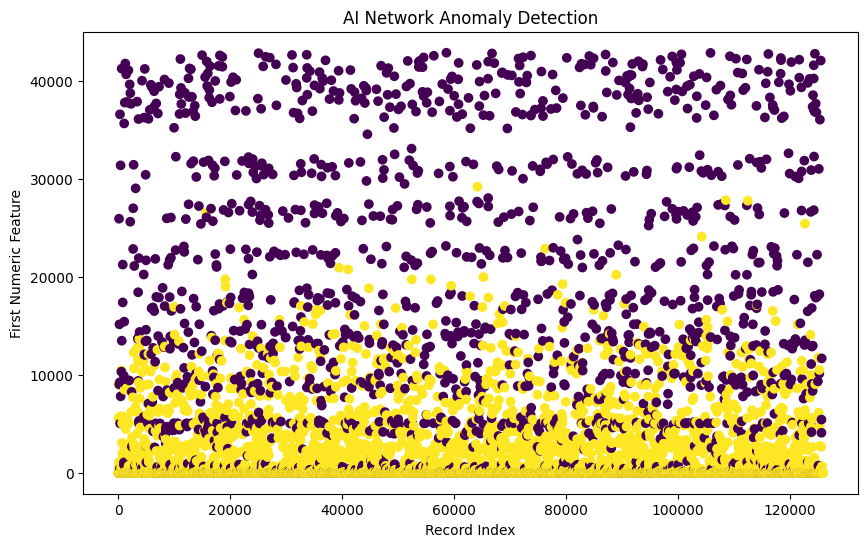

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(numeric_data.index, numeric_data.iloc[:, 0], c=numeric_data["anomaly"])
plt.title("AI Network Anomaly Detection")
plt.xlabel("Record Index")
plt.ylabel("First Numeric Feature")
plt.show()

In [72]:
anomalies = numeric_data[numeric_data["anomaly"] == -1]
print(anomalies.shape)
anomalies.head(10)

(6299, 40)


,0,4,5,6,7,8,9,10,11,12,...,33,34,35,36,37,38,39,40,42,anomaly
62,0,0,0,0,0,0,0,0,0,0,...,0.00,0.84,0.0,0.00,0.07,0.0,0.62,1.00,18,-1
102,0,0,0,0,0,0,0,0,0,0,...,1.00,0.00,1.0,0.15,0.00,0.0,1.00,0.68,21,-1
115,25950,1,0,0,0,0,0,0,0,0,...,0.01,0.69,1.0,0.00,0.00,0.0,1.00,1.00,15,-1
146,0,0,0,0,0,0,0,0,0,0,...,0.00,1.00,1.0,0.00,1.00,1.0,0.00,0.00,18,-1
165,9015,1,0,0,0,0,0,0,0,0,...,0.01,0.74,1.0,0.00,0.00,0.0,1.00,1.00,15,-1
177,0,0,0,0,0,0,0,0,0,0,...,0.00,0.91,0.0,0.00,0.11,0.0,0.89,1.00,18,-1
190,15159,350,1185,0,0,0,6,0,1,0,...,0.56,0.02,0.0,0.00,0.00,0.0,0.00,0.00,2,-1
198,0,0,0,0,0,0,0,0,0,0,...,0.00,0.52,1.0,0.00,0.00,0.0,1.00,1.00,18,-1
210,0,0,0,0,0,0,0,0,0,0,...,0.00,0.80,0.0,0.00,0.03,0.0,0.61,1.00,18,-1
253,9235,1,0,0,0,0,0,0,0,0,...,0.01,0.74,1.0,0.00,0.00,0.0,1.00,1.00,15,-1


In [73]:
labels = data.iloc[:, -2].copy()
labels.name = "label"

results = numeric_data.copy()
results["label"] = labels

results[["anomaly", "label"]].head()

,anomaly,label
0,1,normal
1,1,normal
2,1,neptune
3,1,normal
4,1,normal


In [74]:
results["label"].value_counts().head(20)

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
Name: count, dtype: int64

In [75]:
results["is_attack"] = results["label"].apply(lambda x: 0 if x == "normal" else 1)
results["is_attack"].value_counts()

is_attack
0    67343
1    58630
Name: count, dtype: int64

In [76]:
pd.crosstab(results["anomaly"], results["is_attack"], rownames=["Model Output"], colnames=["Actual Traffic"])

Actual Traffic,0,1
Model Output,,
-1,1512,4787
1,65831,53843


In [77]:
flagged_attacks = results[(results["anomaly"] == -1) & (results["is_attack"] == 1)].shape[0]
total_attacks = results[results["is_attack"] == 1].shape[0]

detection_rate = flagged_attacks / total_attacks if total_attacks > 0 else 0
print("Flagged attacks:", flagged_attacks)
print("Total attacks:", total_attacks)
print("Approximate attack detection rate:", round(detection_rate * 100, 2), "%")

Flagged attacks: 4787
Total attacks: 58630
Approximate attack detection rate: 8.16 %


In [78]:
false_positives = results[(results["anomaly"] == -1) & (results["is_attack"] == 0)].shape[0]
total_normal = results[results["is_attack"] == 0].shape[0]

false_positive_rate = false_positives / total_normal if total_normal > 0 else 0
print("False positives:", false_positives)
print("Total normal records:", total_normal)
print("Approximate false positive rate:", round(false_positive_rate * 100, 2), "%")

False positives: 1512
Total normal records: 67343
Approximate false positive rate: 2.25 %


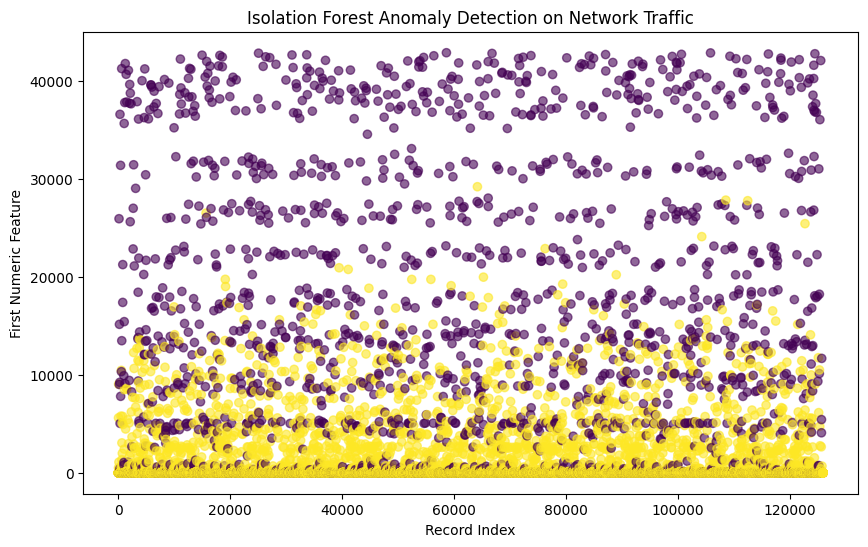

In [79]:
plot_data = results.copy()

plt.figure(figsize=(10,6))
plt.scatter(
    plot_data.index,
    plot_data.iloc[:, 0],
    c=plot_data["anomaly"],
    alpha=0.6
)
plt.title("Isolation Forest Anomaly Detection on Network Traffic")
plt.xlabel("Record Index")
plt.ylabel("First Numeric Feature")
plt.show()

In [80]:
traffic = pd.read_csv("../datasets/syn_attack.csv")

print(traffic.shape)
traffic.head()

(2735, 7)


,No.,Time,Source,Destination,Protocol,Length,Info
0,1,0.000000,192.168.79.131,192.168.79.254,DHCP,358,DHCP Request - Transaction ID 0xafb8a029
1,2,0.001069,192.168.79.254,192.168.79.131,DHCP,342,DHCP ACK - Transaction ID 0xafb8a029
2,3,0.016195,192.168.79.131,192.168.79.2,NBNS,110,Refresh NB DESKTOP-5S7AV1H<20>
3,4,0.034820,fe80::5369:acaa:70e:43fe,ff02::16,ICMPv6,90,Multicast Listener Report Message v2
4,5,0.035735,192.168.79.131,224.0.0.22,IGMPv3,54,Membership Report / Leave group 224.0.0.252


In [81]:
traffic = pd.read_csv("../datasets/syn_attack.csv")

traffic.head()

,No.,Time,Source,Destination,Protocol,Length,Info
0,1,0.000000,192.168.79.131,192.168.79.254,DHCP,358,DHCP Request - Transaction ID 0xafb8a029
1,2,0.001069,192.168.79.254,192.168.79.131,DHCP,342,DHCP ACK - Transaction ID 0xafb8a029
2,3,0.016195,192.168.79.131,192.168.79.2,NBNS,110,Refresh NB DESKTOP-5S7AV1H<20>
3,4,0.034820,fe80::5369:acaa:70e:43fe,ff02::16,ICMPv6,90,Multicast Listener Report Message v2
4,5,0.035735,192.168.79.131,224.0.0.22,IGMPv3,54,Membership Report / Leave group 224.0.0.252


In [82]:
traffic.columns

Index(['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info'], dtype='str')

In [83]:
features = traffic[['Time','Length']].copy()

features.head()

,Time,Length
0,0.000000,358
1,0.001069,342
2,0.016195,110
3,0.034820,90
4,0.035735,54


In [84]:
protocol_encoded = pd.get_dummies(traffic['Protocol'])

features = pd.concat([features, protocol_encoded], axis=1)

features.head()

,Time,Length,ARP,DHCP,ICMPv6,IGMPv3,LLMNR,MDNS,NBNS,NTP,TCP
0,0.000000,358,False,True,False,False,False,False,False,False,False
1,0.001069,342,False,True,False,False,False,False,False,False,False
2,0.016195,110,False,False,False,False,False,False,True,False,False
3,0.034820,90,False,False,True,False,False,False,False,False,False
4,0.035735,54,False,False,False,True,False,False,False,False,False


In [85]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05, random_state=42)

model.fit(features)

features['anomaly'] = model.predict(features)

features['anomaly'].value_counts()

anomaly
 1    2598
-1     137
Name: count, dtype: int64

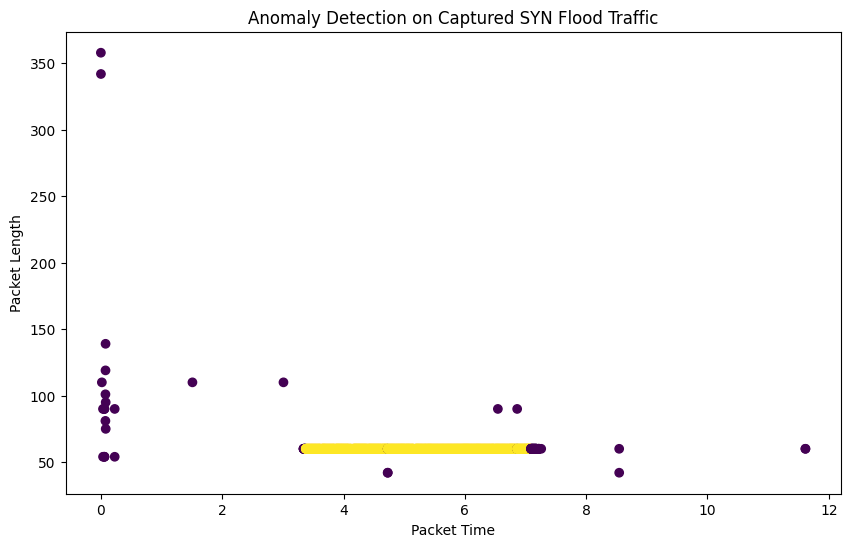

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    features['Time'],
    features['Length'],
    c=features['anomaly']
)

plt.xlabel("Packet Time")
plt.ylabel("Packet Length")
plt.title("Anomaly Detection on Captured SYN Flood Traffic")

plt.show()

In [87]:
import pandas as pd

normal = pd.read_csv("../datasets/normal_ping.csv")
scan = pd.read_csv("../datasets/port_scan.csv")
dos = pd.read_csv("../datasets/syn_flood.csv")

normal["traffic_type"] = "normal"
scan["traffic_type"] = "scan"
dos["traffic_type"] = "dos"

print("Normal shape:", normal.shape)
print("Scan shape:", scan.shape)
print("DoS shape:", dos.shape)

Normal shape: (27, 8)
Scan shape: (448, 8)
DoS shape: (21, 8)


In [88]:
traffic = pd.concat([normal, scan, dos], ignore_index=True)

print("Combined shape:", traffic.shape)
traffic.head()

Combined shape: (496, 8)


,No.,Time,Source,Destination,Protocol,Length,Info,traffic_type
0,1,0.000000,VMware_c0:00:08,Broadcast,ARP,60,Who has 192.168.79.2? Tell 192.168.79.1,normal
1,2,2.932114,192.168.79.132,192.168.79.131,ICMP,98,"Echo (ping) request id=0x0005, seq=1/256, ttl...",normal
2,3,2.932403,192.168.79.131,192.168.79.132,ICMP,98,"Echo (ping) reply id=0x0005, seq=1/256, ttl...",normal
3,4,3.222876,192.168.79.131,20.59.87.227,TCP,55,62048 > 443 [ACK] Seq=1 Ack=1 Win=64071 Len=1,normal
4,5,3.223747,20.59.87.227,192.168.79.131,TCP,60,443 > 62048 [ACK] Seq=1 Ack=2 Win=64240 Len=0,normal


In [89]:
print(traffic.columns)

Index(['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info',
       'traffic_type'],
      dtype='str')


In [90]:
features = traffic[["Time", "Length", "Protocol"]].copy()
features.head()

,Time,Length,Protocol
0,0.000000,60,ARP
1,2.932114,98,ICMP
2,2.932403,98,ICMP
3,3.222876,55,TCP
4,3.223747,60,TCP


In [91]:
protocol_dummies = pd.get_dummies(features["Protocol"], prefix="proto")
features = pd.concat([features.drop(columns=["Protocol"]), protocol_dummies], axis=1)

features.head()

,Time,Length,proto_ARP,proto_DNS,proto_ICMP,proto_NBNS,proto_TCP
0,0.000000,60,True,False,False,False,False
1,2.932114,98,False,False,True,False,False
2,2.932403,98,False,False,True,False,False
3,3.222876,55,False,False,False,False,True
4,3.223747,60,False,False,False,False,True


In [92]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.10, random_state=42)
model.fit(features)

features["anomaly"] = model.predict(features)
features["traffic_type"] = traffic["traffic_type"]

features["anomaly"].value_counts()

anomaly
 1    446
-1     50
Name: count, dtype: int64

In [93]:
pd.crosstab(features["traffic_type"], features["anomaly"])

anomaly,-1,1
traffic_type,,
dos,15,6
normal,24,3
scan,11,437


In [94]:
summary = features.groupby("traffic_type")["anomaly"].apply(lambda x: (x == -1).mean() * 100)
summary = summary.round(2)

print("Percent flagged as anomalous:")
print(summary)

Percent flagged as anomalous:
traffic_type
dos       71.43
normal    88.89
scan       2.46
Name: anomaly, dtype: float64


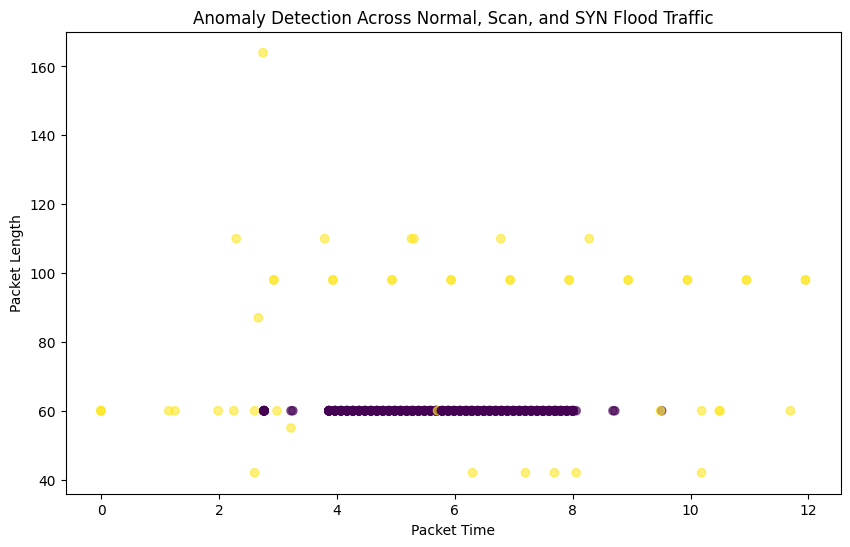

In [95]:
import matplotlib.pyplot as plt

colors = features["anomaly"].map({1: 0, -1: 1})

plt.figure(figsize=(10,6))
plt.scatter(features["Time"], features["Length"], c=colors, alpha=0.6)
plt.xlabel("Packet Time")
plt.ylabel("Packet Length")
plt.title("Anomaly Detection Across Normal, Scan, and SYN Flood Traffic")
plt.show()

In [96]:
anomalies = features[features["anomaly"] == -1]
print(anomalies.shape)
anomalies.head(20)

(50, 9)


,Time,Length,proto_ARP,proto_DNS,proto_ICMP,proto_NBNS,proto_TCP,anomaly,traffic_type
0,0.000000,60,True,False,False,False,False,-1,normal
1,2.932114,98,False,False,True,False,False,-1,normal
2,2.932403,98,False,False,True,False,False,-1,normal
3,3.222876,55,False,False,False,False,True,-1,normal
5,3.933999,98,False,False,True,False,False,-1,normal
6,3.934167,98,False,False,True,False,False,-1,normal
7,4.936043,98,False,False,True,False,False,-1,normal
8,4.936241,98,False,False,True,False,False,-1,normal
9,5.938279,98,False,False,True,False,False,-1,normal
10,5.938417,98,False,False,True,False,False,-1,normal


In [97]:
plt.savefig("../images/anomaly_plot.png")

FileNotFoundError: [Errno 2] No such file or directory: '../images/anomaly_plot.png'

<Figure size 640x480 with 0 Axes>